In [6]:
#time series is a set of data points indexed in time order
import pandas as pd
df=pd.read_csv("ab.csv")
df.columns=df.columns.str.strip()
print(df.columns)
df=pd.read_csv("ab.csv",parse_dates=["date"])
df
#the error was due to 
#The second read_csv line reads the file again from scratch —
#so it doesn’t know about your str.strip() changes!
#That df.columns = df.columns.str.strip() only cleaned the column names in the first dataframe, but when you re-read the CSV file, those cleaned names are gone.

Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


ValueError: Missing column provided to 'parse_dates': 'date'

In [10]:
df = pd.read_csv("ab.csv")
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])
df
#type(df.date[0])
#now the index of df is 0,1,2,3,4,5 but what i wanna make is make the date column as index

,date,open,high,low,close,volume
0,2001-01-01,180,987,-369,1,1.2
1,2002-02-02,190,654,-963,2,2.3
2,2003-03-03,150,321,-753,32,4.5
3,2004-04-04,123,-456,-159,55,5.6
4,2005-05-05,456,-258,168,69,6.7
5,2006-06-06,789,-147,752,85,7.8


In [12]:
df=pd.read_csv("ab.csv",parse_dates=["date "],index_col="date ")
df
df.index
#You write...	What pandas looks for	Works?	Use when...
#df["2004-04-04"]	A column named “2004-04-04”	❌	Only if you want a column
#df.loc["2004-04-04"]	A row index value (date)	✅	You set date as index
#df.iloc[3]	Row by position (0-based)	✅	You want the 4th row

DatetimeIndex(['2001-01-01', '2002-02-02', '2003-03-03', '2004-04-04',
               '2005-05-05', '2006-06-06'],
              dtype='datetime64[ns]', name='date ', freq=None)

In [19]:

df.loc["2004-04-04"]
#the below line raises an error bcz:
#df = pd.read_csv("ab.csv", parse_dates=["date "], index_col="date ")
#That means:
#"date " column is parsed as datetime, ✅
#Then it is set as the index of your DataFrame. ✅
#⚙️ So after this line…
#Your “date” column is no longer a column —
#it has been moved into the index.
#🔍 To see this:
#Run:
#print(df.columns)
#print(df.index)

#You’ll see something like:
#Index(['open ', 'high ', 'low', 'close', 'volume'], dtype='object')
#DatetimeIndex(['2001-01-01', '2002-02-02', ...], dtype='datetime64[ns]', name='date ')
#Notice:

#✅ The index name is 'date '
#🚫 There is no column named 'date ' anymore
#That’s exactly why:

#df["date "]
#raises a KeyError — that column doesn’t exist in the DataFrame’s columns anymore.

#✅ How to correctly access it now
#If you want to access a specific date, use the index:


#df.loc["2004-04-04"]
#If you want to get the index itself (i.e. the dates):
#df.index
#If you really want “date” back as a normal column, you can reset the index:
#df = df.reset_index()
#print(df.columns)
#Now "date " will appear again as a regular column,
#and you can do:

#df["date "]
#✅ Summary table
#You want to...	Correct command	Explanation
#See all dates (index)	df.index	Because date is the index
#Access a specific date row	df.loc["2004-04-04"]	Look up by index
#Bring date column back	df.reset_index(inplace=True)	Converts index back to column
#Access the column after reset	df["date"]	Now it’s a normal column again
#df["date "]

open      123.0
high     -456.0
low      -159.0
close      55.0
volume      5.6
Name: 2004-04-04 00:00:00, dtype: float64

In [20]:
#this means we can retrieve the values from "2001-01-01":"2002-02-02"
df.loc["2001-01-01":"2002-02-02"]

,open,high,low,close,volume
date,,,,,
2001-01-01,180,987,-369,1,1.2
2002-02-02,190,654,-963,2,2.3


In [22]:
#now i want to perform mean of monthly data from close column so what we can do is "df.columnname.resample('M').mean()"
df.close.resample('ME').mean()

date 
2001-01-31     1.0
2001-02-28     NaN
2001-03-31     NaN
2001-04-30     NaN
2001-05-31     NaN
              ... 
2006-02-28     NaN
2006-03-31     NaN
2006-04-30     NaN
2006-05-31     NaN
2006-06-30    85.0
Freq: ME, Name: close, Length: 66, dtype: float64

In [23]:
%matplotlib inline
df.close.resample('ME').mean().plot()

#this doesn't plot a plot bcz:
#🧩 Step 1 — Check if your index is actually a DatetimeIndex
#resample() only works when your index is a DatetimeIndex.
#Run this first:
#print(df.index)
#print(df.index.dtype)

#You should see something like:
#DatetimeIndex(['2001-01-01', '2002-02-02', ...], dtype='datetime64[ns]', name='date ')

#If instead you see:
#Index(['2001-01-01', '2002-02-02', ...], dtype='object')
#then your index is not datetime, so resample() silently fails to group anything → no plot.

#✅ Fix:
#Make sure to parse dates and set them as index properly:
#df = pd.read_csv("ab.csv", parse_dates=["date "], index_col="date ")

#🧩 Step 2 — Verify that the column exists and has numeric data
#Run:
#print(df.columns)
#print(df['close'].head())
#If your column name has a space like 'close ' instead of 'close', it won’t match.
#✅ Fix:
#df.columns = df.columns.str.strip()

#🧩 Step 3 — Run the plotting line again
#Now this should work perfectly:
#%matplotlib inline
#df['close'].resample('ME').mean().plot(title='Month-End Mean of Close')
#✅ 'ME' = month-end frequency.
#If you want month-start, use 'MS'.

#🧩 Step 4 — (Optional) Explicitly call plt.show()
#Sometimes, depending on your Jupyter setup, the inline backend may not auto-display plots.
#You can force it:

import matplotlib.pyplot as plt
plt.show()

#✅ Full clean version (guaranteed to work)
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("ab.csv", parse_dates=["date "], index_col="date ")
df.columns = df.columns.str.strip()
%matplotlib inline
df['close'].resample('ME').mean().plot(title='Month-End Mean of Close')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()


<Axes: xlabel='date '>

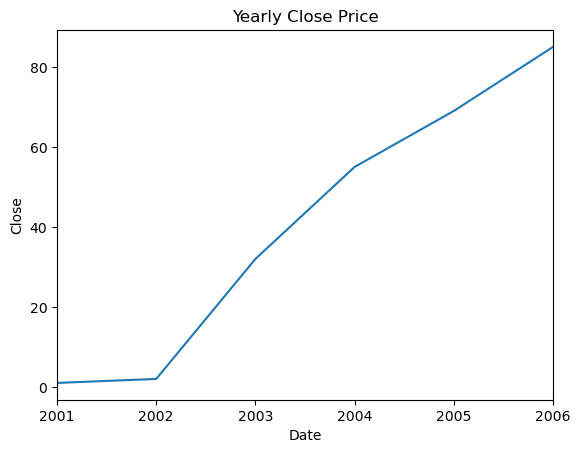

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# read file
df = pd.read_csv("ab.csv", parse_dates=["date "], index_col="date ")

# plot yearly mean
%matplotlib inline
df['close'].resample('YE').mean().plot(title='Yearly Close Price')

plt.xlabel('Date')
plt.ylabel('Close')
plt.show()
